# BNPL Customer Financial Profile Clustering

---

**Project:** Buy Now Pay Later (BNPL) Default Risk Analysis  
**Objective:** Segment BNPL customers into distinct financial profiles based on their shopping behavior, employment status, credit history, and financial metrics using K-Means Clustering.  
**Dataset:** `BNPL_Financial_Default_Risk_Dataset.csv`  
**Date:** September 2026

---

## Business Context

In the Buy Now Pay Later industry, understanding customer financial behavior is critical for risk management, personalized product offerings, and proactive default prevention. Rather than treating all customers uniformly, this analysis applies unsupervised machine learning to discover natural groupings within the customer base.

The resulting customer segments will enable the business to:

- Design targeted credit limit policies per segment
- Tailor collection strategies to each financial profile
- Identify early warning signals for high-risk behavioral patterns
- Optimize marketing spend by understanding spending habits per employment group

## Pipeline Overview

| Step | Description |
| :--- | :--- |
| 1 | Library Imports |
| 2 | Dataset Loading and Initial Inspection |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Preprocessing |
| 5 | Optimal Cluster Selection (Elbow + Silhouette + Davies-Bouldin) |
| 6 | K-Means Model Training |
| 7 | Cluster Profiling and Business Interpretation |
| 8 | Visualization of Clusters |
| 9 | Model and Artifact Persistence |


---

## Step 1: Library Imports

This section loads all required libraries for the end-to-end pipeline.

- **Data Handling:** `pandas` and `numpy` for data manipulation and numerical operations.
- **Visualization:** `matplotlib` and `seaborn` for static plots.
- **Preprocessing:** `scikit-learn` utilities including `StandardScaler`, `OneHotEncoder`, and `ColumnTransformer` to handle mixed-type features.
- **Dimensionality Reduction:** `PCA` (Principal Component Analysis) for projecting high-dimensional feature space into 2D for visualization.
- **Clustering and Evaluation:** `KMeans`, `silhouette_score`, and `davies_bouldin_score` for model fitting and quality assessment.
- **Persistence:** `joblib` for serializing the fitted model and preprocessing pipeline to disk.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED', '#0891B2']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print('All libraries imported successfully.')


All libraries imported successfully.


---

## Step 2: Dataset Loading and Initial Inspection

The dataset is loaded from the `Dataset/` directory relative to the project root. An initial inspection is performed to understand:

- The shape (rows, columns) and column data types
- Volume of missing values per feature
- Basic statistical distributions of numeric features
- Cardinality of categorical features

The `Default_Risk` column (Low, Medium, High) is the labeled ground truth. It will be **excluded from clustering features** and retained separately as an external validation reference to assess how well the discovered clusters align with the known risk labels.


In [2]:
DATA_PATH = '../Dataset/BNPL_Financial_Default_Risk_Dataset.csv'

df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
df.head(10)


Dataset shape: 10,000 rows x 11 columns



,Customer_ID,Age,Employment_Status,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Late_Payment_History,Shopping_Category_Most_Frequent,Average_Transaction_Value_USD,Default_Risk
0,C00001,29,Employed,73405.0,637.0,2,193,No,Fashion,118,Low
1,C00002,64,Employed,53732.0,815.0,0,0,No,Electronics,662,Low
2,C00003,26,Freelancer,69930.0,723.0,2,273,No,Fashion,76,Low
3,C00004,19,Employed,96941.0,716.0,3,421,No,Home/Furniture,449,Low
4,C00005,55,Student,15959.0,675.0,2,145,No,Travel,974,Low
5,C00006,20,Student,19759.0,488.0,3,513,Yes,Electronics,389,Medium
6,C00007,21,Student,7351.0,NaN,2,50,No,Groceries/Essentials,61,Low
7,C00008,53,Freelancer,90887.0,730.0,4,773,No,Electronics,665,Low
8,C00009,42,Freelancer,51148.0,610.0,5,918,No,Electronics,681,Low
9,C00010,47,Employed,115871.0,723.0,2,185,No,Groceries/Essentials,54,Low


In [3]:
print('=== Column Information ===')
df.info()
print()
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0])


=== Column Information ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Customer_ID                      10000 non-null  str    
 1   Age                              10000 non-null  int64  
 2   Employment_Status                10000 non-null  str    
 3   Income_USD                       9695 non-null   float64
 4   Credit_Score                     9702 non-null   float64
 5   Total_BNPL_Active_Loans          10000 non-null  int64  
 6   Total_BNPL_Debt_USD              10000 non-null  int64  
 7   Late_Payment_History             10000 non-null  str    
 8   Shopping_Category_Most_Frequent  10000 non-null  str    
 9   Average_Transaction_Value_USD    10000 non-null  int64  
 10  Default_Risk                     10000 non-null  str    
dtypes: float64(2), int64(4), str(5)
memory usage: 1.1 MB

=== Missing

In [4]:
print('=== Descriptive Statistics: Numeric Features ===')
df.describe(include=['number']).T.round(2)


=== Descriptive Statistics: Numeric Features ===


,count,mean,std,min,25%,50%,75%,max
Age,10000.0,34.25,12.91,18.0,23.0,31.0,43.0,64.0
Income_USD,9695.0,53981.14,29797.37,5000.0,21996.5,58596.0,77073.5,139452.0
Credit_Score,9702.0,663.67,76.22,300.0,620.0,673.0,717.0,850.0
Total_BNPL_Active_Loans,10000.0,2.32,1.85,0.0,1.0,2.0,3.0,10.0
Total_BNPL_Debt_USD,10000.0,348.81,315.10,0.0,142.0,262.5,467.0,2731.0
Average_Transaction_Value_USD,10000.0,331.81,264.36,10.0,98.0,294.5,515.0,1420.0


In [5]:
for col in ['Employment_Status', 'Late_Payment_History',
            'Shopping_Category_Most_Frequent', 'Default_Risk']:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()


--- Employment_Status ---
Employment_Status
Employed      6029
Student       1968
Freelancer    1495
Unemployed     508

--- Late_Payment_History ---
Late_Payment_History
No     7524
Yes    2476

--- Shopping_Category_Most_Frequent ---
Shopping_Category_Most_Frequent
Fashion                 4012
Electronics             2991
Home/Furniture          1512
Travel                   971
Groceries/Essentials     514

--- Default_Risk ---
Default_Risk
Low       8801
Medium     678
High       521



---

## Step 3: Exploratory Data Analysis (EDA)

Before building the clustering model, it is essential to understand the underlying distributions and relationships in the data. This section examines:

1. **Distribution of numeric features** to identify skewness and outliers.
2. **Distribution of categorical features** to understand group compositions.
3. **Relationship between key financial metrics** such as `Income_USD`, `Credit_Score`, and `Total_BNPL_Debt_USD`.
4. **Default risk distribution** across employment status and shopping categories, providing business context for interpreting clusters.


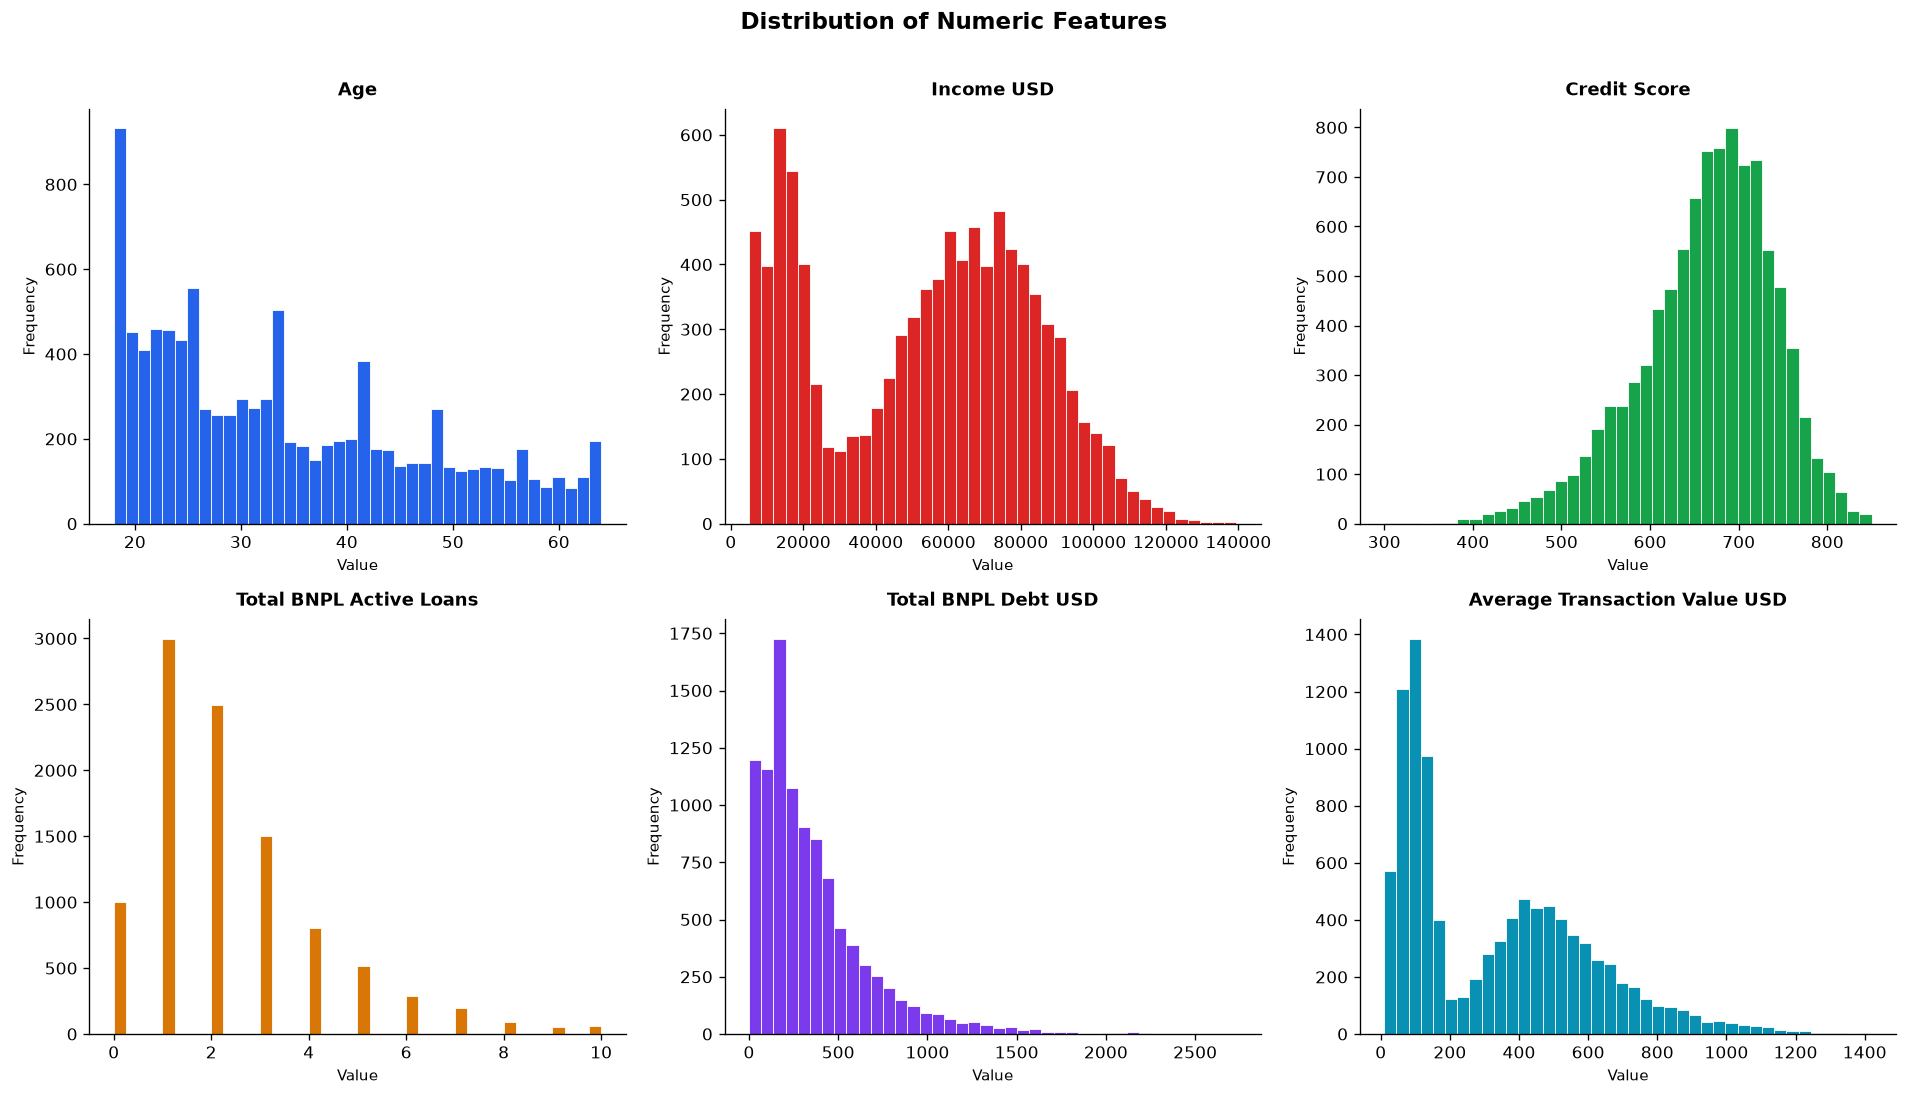

In [6]:
numeric_features = [
    'Age', 'Income_USD', 'Credit_Score', 'Total_BNPL_Active_Loans',
    'Total_BNPL_Debt_USD', 'Average_Transaction_Value_USD'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=40, color=PALETTE[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)

fig.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


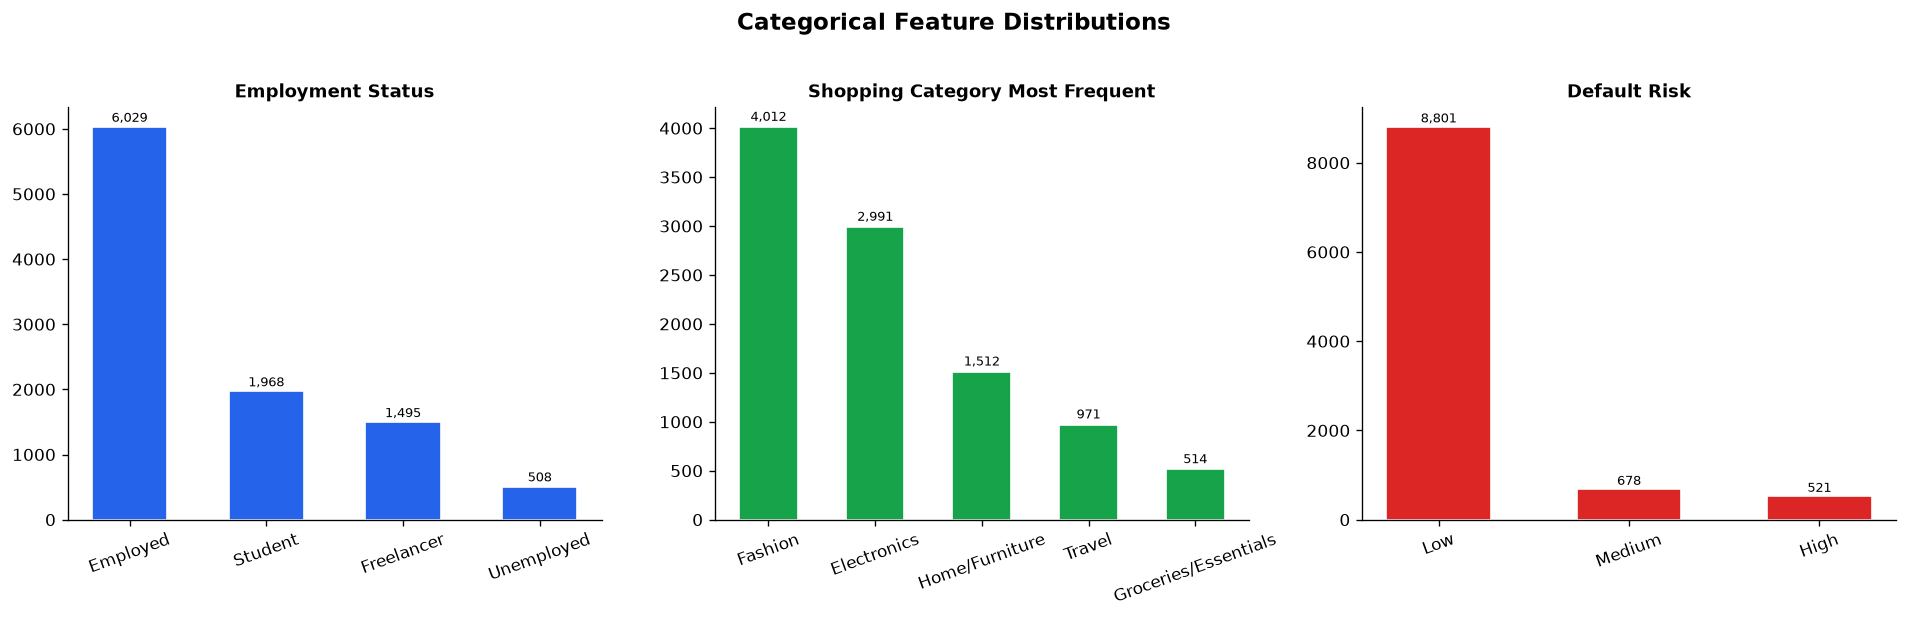

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_plot_cols = ['Employment_Status', 'Shopping_Category_Most_Frequent', 'Default_Risk']
bar_colors = ['#2563EB', '#16A34A', '#DC2626']

for i, col in enumerate(cat_plot_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=bar_colors[i], width=0.55, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2., h + 30,
                     f'{h:,}', ha='center', va='bottom', fontsize=8)
    axes[i].set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

fig.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


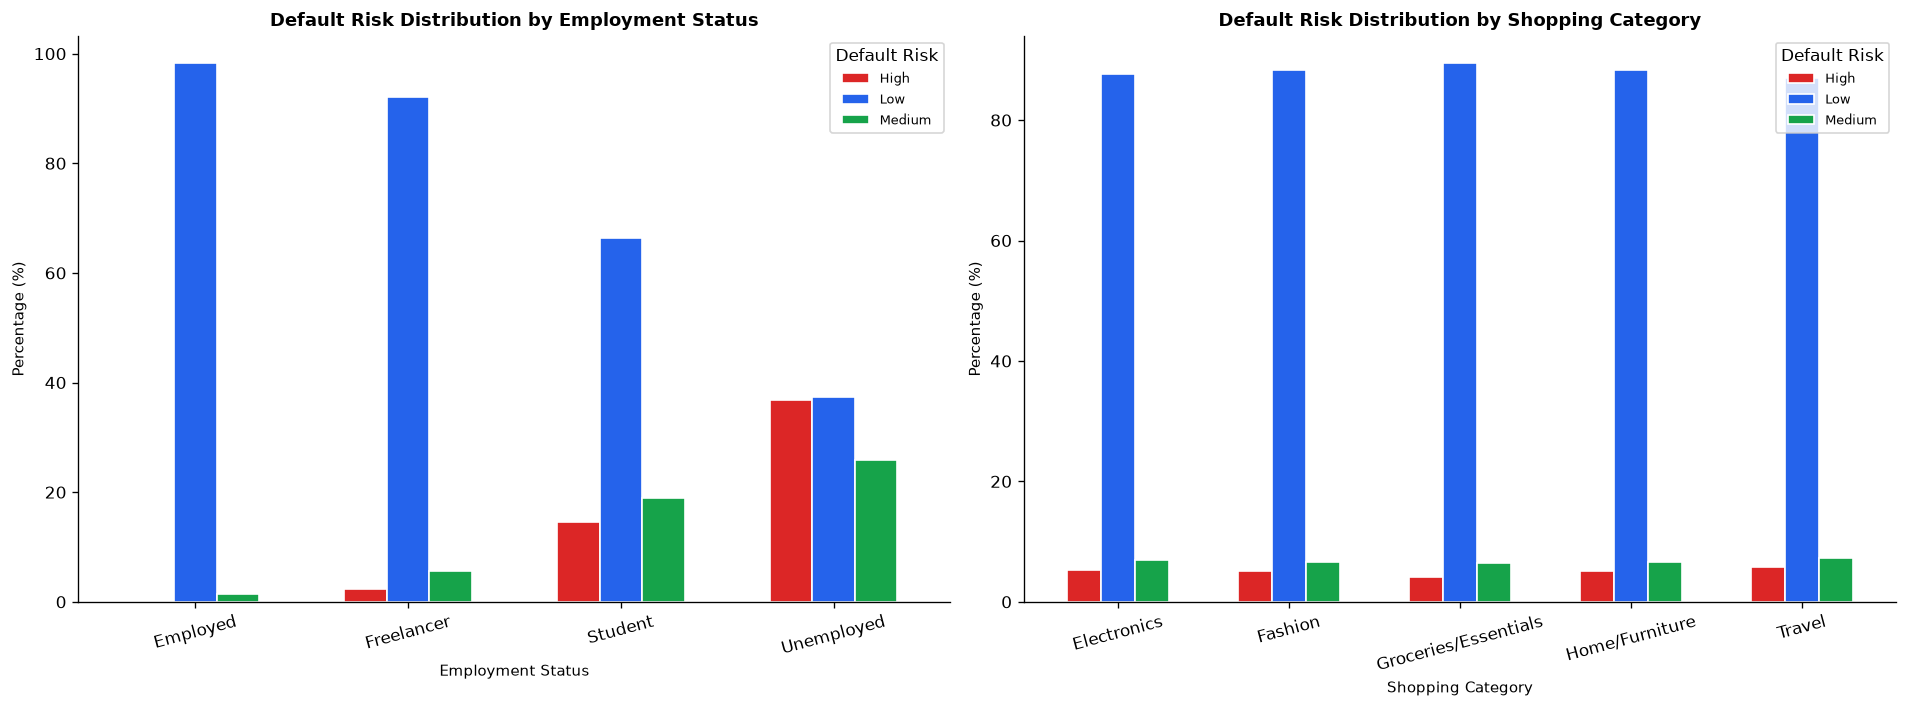

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot1 = df.groupby(['Employment_Status', 'Default_Risk']).size().unstack(fill_value=0)
pivot1_pct = pivot1.div(pivot1.sum(axis=1), axis=0) * 100
pivot1_pct.plot(kind='bar', ax=axes[0],
                color=['#DC2626', '#2563EB', '#16A34A'], edgecolor='white', width=0.6)
axes[0].set_title('Default Risk Distribution by Employment Status',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Employment Status', fontsize=9)
axes[0].set_ylabel('Percentage (%)', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Default Risk', fontsize=8)

pivot2 = df.groupby(['Shopping_Category_Most_Frequent', 'Default_Risk']).size().unstack(fill_value=0)
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0) * 100
pivot2_pct.plot(kind='bar', ax=axes[1],
                color=['#DC2626', '#2563EB', '#16A34A'], edgecolor='white', width=0.6)
axes[1].set_title('Default Risk Distribution by Shopping Category',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Shopping Category', fontsize=9)
axes[1].set_ylabel('Percentage (%)', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Default Risk', fontsize=8)

plt.tight_layout()
plt.show()


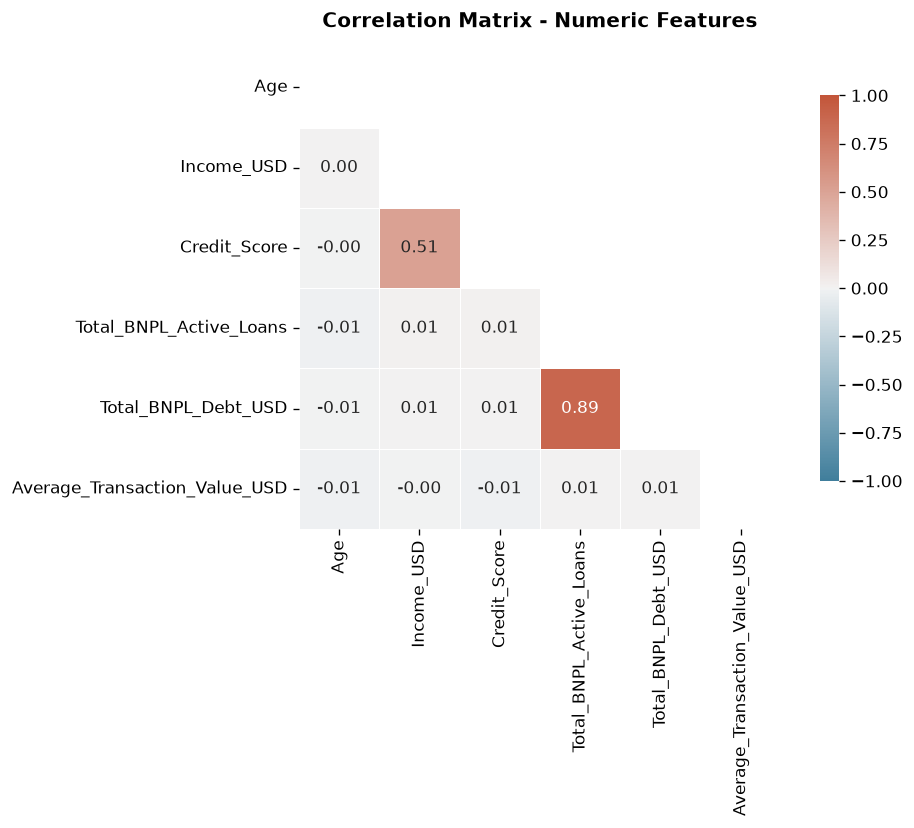

In [9]:
df_corr = df[['Age', 'Income_USD', 'Credit_Score', 'Total_BNPL_Active_Loans',
               'Total_BNPL_Debt_USD', 'Average_Transaction_Value_USD']].copy()
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
    annot=True, fmt='.2f', square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix - Numeric Features', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


---

## Step 4: Data Preprocessing

K-Means operates on Euclidean distance, which requires careful preparation of all features before training. The preprocessing pipeline consists of the following stages:

**Feature Selection**

The following columns are excluded from the feature matrix:

- `Customer_ID`: A unique identifier with no statistical information.
- `Default_Risk`: The ground truth label, preserved separately as an external validation reference.

**Missing Value Imputation**

- `Income_USD` (~3.05% missing) and `Credit_Score` (~2.98% missing) are imputed using the **median strategy**, which is robust to outliers and preserves the distribution shape better than mean imputation for right-skewed financial data.

**Categorical Encoding**

- `Employment_Status`, `Shopping_Category_Most_Frequent`, and `Late_Payment_History` are encoded using **One-Hot Encoding** (`drop='first'` to avoid the dummy variable trap), converting them into binary indicator columns that Euclidean distance can interpret.

**Feature Scaling**

- All numeric features are standardized using `StandardScaler` (zero mean, unit variance). This is critical because features like `Income_USD` (range: ~$7K-$165K) and `Total_BNPL_Active_Loans` (range: 0-8) exist on vastly different scales. Without scaling, high-magnitude features would completely dominate the distance computation, rendering other features effectively irrelevant.

All steps are encapsulated inside a scikit-learn `ColumnTransformer` for clean, reproducible, and serializable preprocessing.


In [10]:
DROP_COLS = ['Customer_ID', 'Default_Risk']

df_model = df.drop(columns=DROP_COLS).copy()
y_external = df['Default_Risk'].copy()

numeric_cols = [
    'Age', 'Income_USD', 'Credit_Score', 'Total_BNPL_Active_Loans',
    'Total_BNPL_Debt_USD', 'Average_Transaction_Value_USD'
]

categorical_cols_model = [
    'Employment_Status', 'Late_Payment_History', 'Shopping_Category_Most_Frequent'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols_model)
])

X_processed = preprocessor.fit_transform(df_model)

cat_feature_names = (
    preprocessor
    .named_transformers_['cat']['encoder']
    .get_feature_names_out(categorical_cols_model)
)
all_feature_names = numeric_cols + list(cat_feature_names)

X_df = pd.DataFrame(X_processed, columns=all_feature_names)

print(f'Preprocessed feature matrix shape: {X_processed.shape}')
print(f'Numeric features   : {len(numeric_cols)}')
print(f'Encoded categorical: {len(cat_feature_names)}')
print(f'Total features     : {X_processed.shape[1]}')
X_df.head(5)


Preprocessed feature matrix shape: (10000, 14)
Numeric features   : 6
Encoded categorical: 8
Total features     : 14


,Age,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Average_Transaction_Value_USD,Employment_Status_Freelancer,Employment_Status_Student,Employment_Status_Unemployed,Late_Payment_History_Yes,Shopping_Category_Most_Frequent_Fashion,Shopping_Category_Most_Frequent_Groceries/Essentials,Shopping_Category_Most_Frequent_Home/Furniture,Shopping_Category_Most_Frequent_Travel
0,-0.406505,0.657035,-0.358892,-0.170947,-0.494493,-0.808813,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2.304405,-0.013285,2.011582,-1.249477,-1.107035,1.249085,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.638868,0.538631,0.786393,-0.170947,-0.240590,-0.967695,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.181050,1.458980,0.693172,0.368318,0.229132,0.443327,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.607314,-1.300328,0.147164,-0.170947,-0.646835,2.429350,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


---

## Step 5: Determining the Optimal Number of Clusters

Selecting the right number of clusters $k$ is the most critical decision in K-Means. Three complementary methods are used:

**Elbow Method (Inertia / Within-Cluster Sum of Squares)**

Inertia measures the sum of squared distances from each point to its assigned cluster centroid. As $k$ increases, inertia monotonically decreases. The optimal $k$ is identified at the "elbow" point, where the rate of decrease sharply changes - meaning adding more clusters yields diminishing returns in cluster compactness.

**Silhouette Score**

The silhouette score for a sample is defined as:

$$s = \\frac{b - a}{\\max(a, b)}$$

Where $a$ is the mean intra-cluster distance and $b$ is the mean nearest-cluster distance. The score ranges from $-1$ (wrong cluster) to $+1$ (dense, well-separated clusters). The optimal $k$ corresponds to the highest silhouette score.

**Davies-Bouldin Score**

A lower Davies-Bouldin score indicates better cluster separation. It measures the average similarity between each cluster and its most similar one, providing a third independent signal to confirm the optimal $k$.


In [11]:
K_RANGE = range(2, 11)

inertia_values = []
silhouette_scores = []
davies_bouldin_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    lbl = km.fit_predict(X_processed)
    inertia_values.append(km.inertia_)
    sil = silhouette_score(X_processed, lbl, sample_size=3000, random_state=RANDOM_STATE)
    db  = davies_bouldin_score(X_processed, lbl)
    silhouette_scores.append(sil)
    davies_bouldin_scores.append(db)
    print(f'k={k:2d} | Inertia: {km.inertia_:>12,.1f} | '
          f'Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}')

print('\nEvaluation complete.')


k= 2 | Inertia:     58,079.1 | Silhouette: 0.2020 | Davies-Bouldin: 1.8179
k= 3 | Inertia:     48,212.8 | Silhouette: 0.1978 | Davies-Bouldin: 1.6665
k= 4 | Inertia:     42,632.1 | Silhouette: 0.1764 | Davies-Bouldin: 1.6338
k= 5 | Inertia:     39,235.6 | Silhouette: 0.1671 | Davies-Bouldin: 1.4953
k= 6 | Inertia:     37,146.1 | Silhouette: 0.1632 | Davies-Bouldin: 1.6647
k= 7 | Inertia:     35,375.5 | Silhouette: 0.1539 | Davies-Bouldin: 1.7260
k= 8 | Inertia:     33,853.7 | Silhouette: 0.1503 | Davies-Bouldin: 1.7883
k= 9 | Inertia:     32,654.8 | Silhouette: 0.1493 | Davies-Bouldin: 1.7612
k=10 | Inertia:     31,486.0 | Silhouette: 0.1513 | Davies-Bouldin: 1.7082

Evaluation complete.


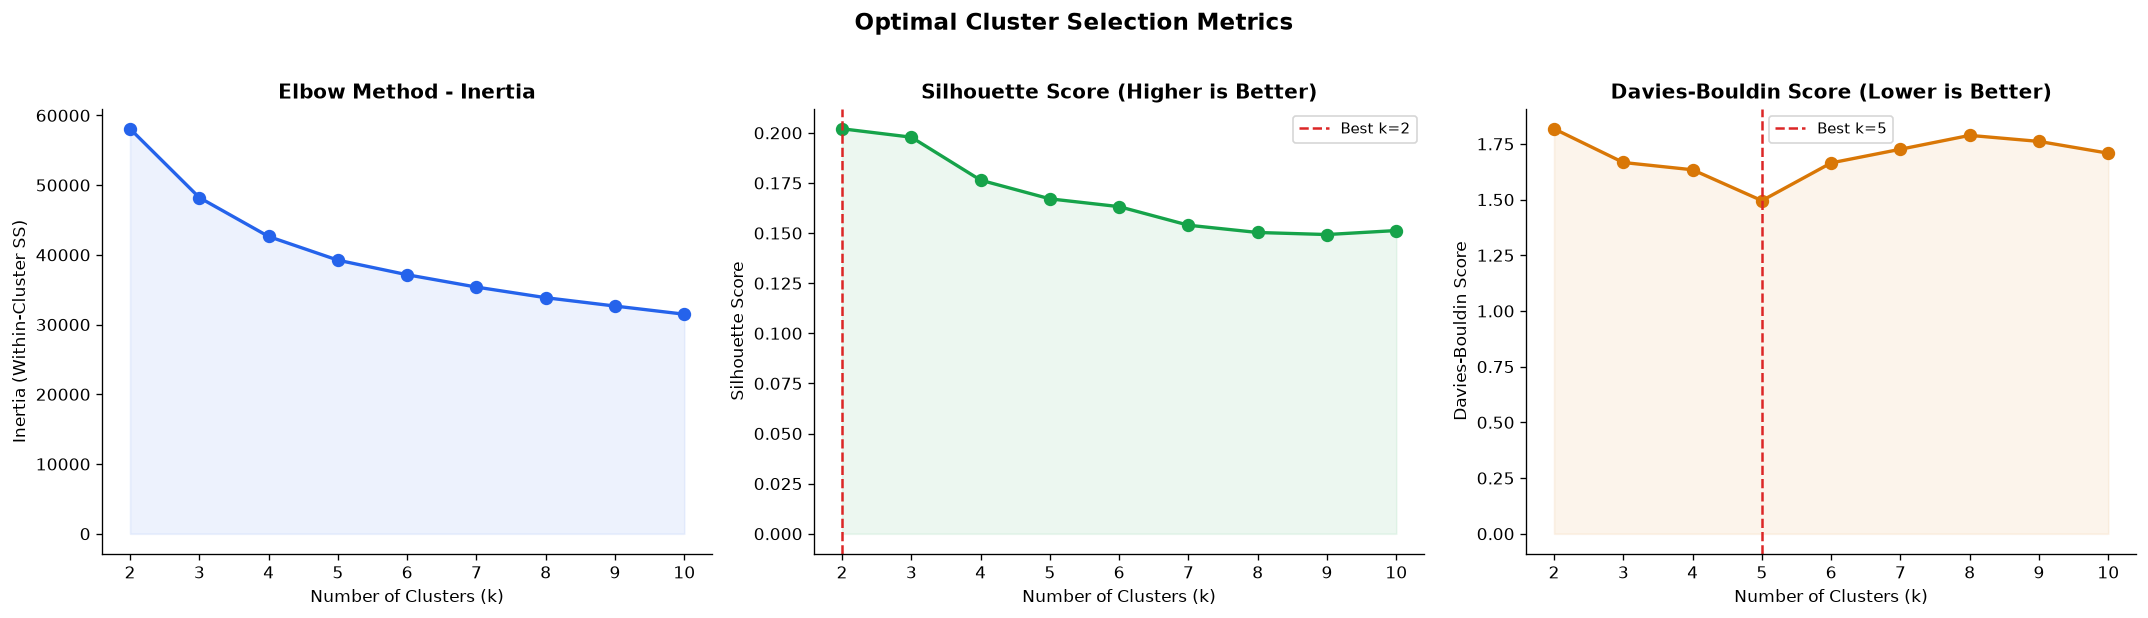


Best k by Silhouette Score   : 2
Best k by Davies-Bouldin Score: 5


In [12]:
k_list = list(K_RANGE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_list, inertia_values, 'o-', color='#2563EB', linewidth=2, markersize=7)
axes[0].fill_between(k_list, inertia_values, alpha=0.08, color='#2563EB')
axes[0].set_title('Elbow Method - Inertia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_xticks(k_list)

best_sil_k = k_list[np.argmax(silhouette_scores)]
axes[1].plot(k_list, silhouette_scores, 'o-', color='#16A34A', linewidth=2, markersize=7)
axes[1].fill_between(k_list, silhouette_scores, alpha=0.08, color='#16A34A')
axes[1].axvline(best_sil_k, linestyle='--', color='#DC2626', linewidth=1.5,
                label=f'Best k={best_sil_k}')
axes[1].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_list)
axes[1].legend(fontsize=9)

best_db_k = k_list[np.argmin(davies_bouldin_scores)]
axes[2].plot(k_list, davies_bouldin_scores, 'o-', color='#D97706', linewidth=2, markersize=7)
axes[2].fill_between(k_list, davies_bouldin_scores, alpha=0.08, color='#D97706')
axes[2].axvline(best_db_k, linestyle='--', color='#DC2626', linewidth=1.5,
                label=f'Best k={best_db_k}')
axes[2].set_title('Davies-Bouldin Score (Lower is Better)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_xticks(k_list)
axes[2].legend(fontsize=9)

plt.suptitle('Optimal Cluster Selection Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Model/artifacts/cluster_selection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest k by Silhouette Score   : {best_sil_k}')
print(f'Best k by Davies-Bouldin Score: {best_db_k}')


In [13]:
metrics_df = pd.DataFrame({
    'k': k_list,
    'Inertia': inertia_values,
    'Silhouette_Score': silhouette_scores,
    'Davies_Bouldin_Score': davies_bouldin_scores
})

metrics_df['Silhouette_Rank'] = metrics_df['Silhouette_Score'].rank(ascending=False).astype(int)
metrics_df['DB_Rank']         = metrics_df['Davies_Bouldin_Score'].rank(ascending=True).astype(int)
metrics_df['Combined_Rank']   = metrics_df['Silhouette_Rank'] + metrics_df['DB_Rank']

print('Cluster Evaluation Summary:')
print(metrics_df.round(4).to_string(index=False))

OPTIMAL_K = int(metrics_df.loc[metrics_df['Combined_Rank'].idxmin(), 'k'])
print(f'\nSelected optimal number of clusters: k = {OPTIMAL_K}')


Cluster Evaluation Summary:
 k    Inertia  Silhouette_Score  Davies_Bouldin_Score  Silhouette_Rank  DB_Rank  Combined_Rank
 2 58079.1016            0.2020                1.8179                1        9             10
 3 48212.7678            0.1978                1.6665                2        4              6
 4 42632.1461            0.1764                1.6338                3        2              5
 5 39235.5869            0.1671                1.4953                4        1              5
 6 37146.1249            0.1632                1.6647                5        3              8
 7 35375.4614            0.1539                1.7260                6        6             12
 8 33853.6724            0.1503                1.7883                8        8             16
 9 32654.7819            0.1493                1.7612                9        7             16
10 31485.9504            0.1513                1.7082                7        5             12

Selected optimal numb

---

## Step 6: K-Means Model Training

With the optimal $k$ determined, the final K-Means model is trained using the following configuration:

- **`init='k-means++'`**: Uses the K-Means++ centroid initialization strategy, which selects initial centroids that are spread out across the data space. This dramatically reduces the probability of converging to a poor local minimum compared to random initialization.
- **`n_init=20`**: The algorithm is run 20 times with different centroid seeds. The final result is the one with the lowest inertia, ensuring a more globally optimal solution.
- **`max_iter=500`**: Maximum number of EM iterations per run, providing sufficient convergence time.
- **`random_state=42`**: Fixed seed for full reproducibility.

After training, the cluster label for each customer is appended to the original dataframe for downstream profiling and analysis.


In [14]:
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=RANDOM_STATE
)

cluster_labels = kmeans_final.fit_predict(X_processed)

df['Cluster']       = cluster_labels
df['Cluster_Label'] = df['Cluster'].astype(str)

final_silhouette = silhouette_score(
    X_processed, cluster_labels, sample_size=5000, random_state=RANDOM_STATE
)
final_db = davies_bouldin_score(X_processed, cluster_labels)

print('=== Final K-Means Model Performance ===')
print(f'Number of Clusters     : {OPTIMAL_K}')
print(f'Final Inertia          : {kmeans_final.inertia_:,.2f}')
print(f'Silhouette Score       : {final_silhouette:.4f}')
print(f'Davies-Bouldin Score   : {final_db:.4f}')
print(f'Iterations to Converge : {kmeans_final.n_iter_}')
print()
print('Cluster Size Distribution:')
print(df['Cluster'].value_counts().sort_index().to_string())


=== Final K-Means Model Performance ===
Number of Clusters     : 4
Final Inertia          : 42,632.11
Silhouette Score       : 0.1754
Davies-Bouldin Score   : 1.6339
Iterations to Converge : 10

Cluster Size Distribution:
Cluster
0    3053
1    2356
2    3167
3    1424


---

## Step 7: Cluster Profiling and Business Interpretation

Raw cluster labels (0, 1, 2, ...) carry no inherent business meaning. This section transforms them into interpretable financial customer personas by analyzing the statistical properties of each cluster across all original features.

The profiling process computes:

- **Numeric summaries:** Mean values of financial and behavioral metrics per cluster, normalized relative to the population mean for comparative analysis.
- **Categorical composition:** Distribution of `Employment_Status`, `Shopping_Category_Most_Frequent`, and `Late_Payment_History` per cluster.
- **Default Risk alignment:** Proportion of Low, Medium, and High default risk labels within each cluster, serving as an external quality check.

Based on these statistical signatures, each cluster is assigned a descriptive persona name reflecting the customer archetype it represents.


In [15]:
numeric_profile_cols = [
    'Age', 'Income_USD', 'Credit_Score', 'Total_BNPL_Active_Loans',
    'Total_BNPL_Debt_USD', 'Average_Transaction_Value_USD'
]

cluster_numeric_profile = df.groupby('Cluster')[numeric_profile_cols].mean().round(2)
cluster_numeric_profile['Cluster_Size']     = df.groupby('Cluster').size()
cluster_numeric_profile['Cluster_Size_Pct'] = (
    cluster_numeric_profile['Cluster_Size'] / len(df) * 100
).round(2)

print('=== Numeric Profile per Cluster ===')
cluster_numeric_profile


=== Numeric Profile per Cluster ===


,Age,Income_USD,Credit_Score,Total_BNPL_Active_Loans,Total_BNPL_Debt_USD,Average_Transaction_Value_USD,Cluster_Size,Cluster_Size_Pct
Cluster,,,,,,,,
0,34.18,68295.88,694.82,1.70,245.40,101.47,3053,30.53
1,34.32,16303.01,576.67,1.83,265.10,320.37,2356,23.56
2,34.28,67847.03,694.20,1.73,249.20,563.89,3167,31.67
3,34.21,56536.88,673.76,5.76,930.53,328.41,1424,14.24


In [16]:
print('=== Default Risk Distribution per Cluster (%) ===')
risk_dist = df.groupby(['Cluster', 'Default_Risk']).size().unstack(fill_value=0)
risk_dist_pct = risk_dist.div(risk_dist.sum(axis=1), axis=0).mul(100).round(2)
print(risk_dist_pct.to_string())

print('\n=== Employment Status Distribution per Cluster (%) ===')
emp_dist = df.groupby(['Cluster', 'Employment_Status']).size().unstack(fill_value=0)
emp_dist_pct = emp_dist.div(emp_dist.sum(axis=1), axis=0).mul(100).round(2)
print(emp_dist_pct.to_string())

print('\n=== Shopping Category Distribution per Cluster (%) ===')
shop_dist = df.groupby(['Cluster', 'Shopping_Category_Most_Frequent']).size().unstack(fill_value=0)
shop_dist_pct = shop_dist.div(shop_dist.sum(axis=1), axis=0).mul(100).round(2)
print(shop_dist_pct.to_string())

print('\n=== Late Payment History per Cluster (%) ===')
late_dist = df.groupby(['Cluster', 'Late_Payment_History']).size().unstack(fill_value=0)
late_dist_pct = late_dist.div(late_dist.sum(axis=1), axis=0).mul(100).round(2)
print(late_dist_pct.to_string())


=== Default Risk Distribution per Cluster (%) ===
Default_Risk   High    Low  Medium
Cluster                           
0              0.16  99.54    0.29
1             11.97  68.80   19.23
2              0.16  99.21    0.63
3             16.08  70.15   13.76

=== Employment Status Distribution per Cluster (%) ===
Employment_Status  Employed  Freelancer  Student  Unemployed
Cluster                                                     
0                     81.00       16.48     2.06        0.46
1                      3.31       10.53    67.78       18.38
2                     80.96       15.95     2.75        0.35
3                     64.19       16.78    15.52        3.51

=== Shopping Category Distribution per Cluster (%) ===
Shopping_Category_Most_Frequent  Electronics  Fashion  Groceries/Essentials  Home/Furniture  Travel
Cluster                                                                                            
0                                       4.49    83.59         

In [17]:
global_means = df[numeric_profile_cols].mean()

print('=== Cluster Profile Relative to Population Mean ===')
print('Values above 0 indicate the cluster is ABOVE population average; below 0 means BELOW.')
print()
relative_profile = (
    (cluster_numeric_profile[numeric_profile_cols] - global_means) / global_means * 100
).round(1)
relative_profile.columns = [f'{c} (% vs Avg)' for c in relative_profile.columns]
relative_profile


=== Cluster Profile Relative to Population Mean ===
Values above 0 indicate the cluster is ABOVE population average; below 0 means BELOW.



,Age (% vs Avg),Income_USD (% vs Avg),Credit_Score (% vs Avg),Total_BNPL_Active_Loans (% vs Avg),Total_BNPL_Debt_USD (% vs Avg),Average_Transaction_Value_USD (% vs Avg)
Cluster,,,,,,
0,-0.2,26.5,4.7,-26.6,-29.6,-69.4
1,0.2,-69.8,-13.1,-21.0,-24.0,-3.4
2,0.1,25.7,4.6,-25.3,-28.6,69.9
3,-0.1,4.7,1.5,148.6,166.8,-1.0


In [18]:
unique_clusters = sorted(df['Cluster'].unique())

for cluster_id in unique_clusters:
    subset = df[df['Cluster'] == cluster_id]
    avg_income   = subset['Income_USD'].mean()
    avg_credit   = subset['Credit_Score'].mean()
    avg_debt     = subset['Total_BNPL_Debt_USD'].mean()
    late_pct     = (subset['Late_Payment_History'] == 'Yes').mean() * 100
    dom_emp      = subset['Employment_Status'].mode()[0]
    dom_shop     = subset['Shopping_Category_Most_Frequent'].mode()[0]
    high_risk    = (subset['Default_Risk'] == 'High').mean() * 100
    print(f'Cluster {cluster_id}:')
    print(f'  Avg Income         : ${avg_income:,.0f}')
    print(f'  Avg Credit Score   : {avg_credit:.0f}')
    print(f'  Avg BNPL Debt      : ${avg_debt:,.0f}')
    print(f'  Late Payment Rate  : {late_pct:.1f}%')
    print(f'  Dominant Employment: {dom_emp}')
    print(f'  Dominant Shopping  : {dom_shop}')
    print(f'  High Default Rate  : {high_risk:.1f}%')
    print()


Cluster 0:
  Avg Income         : $68,296
  Avg Credit Score   : 695
  Avg BNPL Debt      : $245
  Late Payment Rate  : 15.6%
  Dominant Employment: Employed
  Dominant Shopping  : Fashion
  High Default Rate  : 0.2%

Cluster 1:
  Avg Income         : $16,303
  Avg Credit Score   : 577
  Avg BNPL Debt      : $265
  Late Payment Rate  : 51.0%
  Dominant Employment: Student
  Dominant Shopping  : Fashion
  High Default Rate  : 12.0%

Cluster 2:
  Avg Income         : $67,847
  Avg Credit Score   : 694
  Avg BNPL Debt      : $249
  Late Payment Rate  : 15.2%
  Dominant Employment: Employed
  Dominant Shopping  : Electronics
  High Default Rate  : 0.2%

Cluster 3:
  Avg Income         : $56,537
  Avg Credit Score   : 674
  Avg BNPL Debt      : $931
  Late Payment Rate  : 22.4%
  Dominant Employment: Employed
  Dominant Shopping  : Fashion
  High Default Rate  : 16.1%



In [19]:
def assign_persona(cluster_id, df_full):
    sub     = df_full[df_full['Cluster'] == cluster_id]
    pop     = df_full
    inc_r   = sub['Income_USD'].mean()  / pop['Income_USD'].mean()
    crd_r   = sub['Credit_Score'].mean() / pop['Credit_Score'].mean()
    dbt_r   = sub['Total_BNPL_Debt_USD'].mean() / pop['Total_BNPL_Debt_USD'].mean()
    late    = (sub['Late_Payment_History'] == 'Yes').mean() * 100
    dom_emp = sub['Employment_Status'].mode()[0]
    if crd_r >= 1.05 and inc_r >= 1.05 and late < 20:
        return 'Prime Stable Customers'
    if inc_r < 0.65 or dom_emp in ['Student', 'Unemployed']:
        if late >= 25 or dbt_r >= 1.2:
            return 'High-Risk Financially Strained'
        return 'Low-Income Cautious Shoppers'
    if dbt_r >= 1.3 and late >= 30:
        return 'Over-Leveraged Borrowers'
    if inc_r >= 0.9 and dbt_r < 0.8:
        return 'Mid-Income Responsible Spenders'
    return 'Average Profile Customers'

persona_map = {cid: assign_persona(cid, df) for cid in unique_clusters}
df['Persona'] = df['Cluster'].map(persona_map)

print('Cluster to Persona Mapping:')
for cid, persona in persona_map.items():
    size = (df['Cluster'] == cid).sum()
    print(f'  Cluster {cid}: {persona}  ({size:,} customers)')


Cluster to Persona Mapping:
  Cluster 0: Mid-Income Responsible Spenders  (3,053 customers)
  Cluster 1: High-Risk Financially Strained  (2,356 customers)
  Cluster 2: Mid-Income Responsible Spenders  (3,167 customers)
  Cluster 3: Average Profile Customers  (1,424 customers)


In [20]:
cluster_summary_rows = []

for cid in sorted(df['Cluster'].unique()):
    sub = df[df['Cluster'] == cid]
    cluster_summary_rows.append({
        'Cluster_ID'          : cid,
        'Persona'             : persona_map[cid],
        'Size'                : len(sub),
        'Size_Pct'            : round(len(sub) / len(df) * 100, 2),
        'Avg_Age'             : round(sub['Age'].mean(), 1),
        'Avg_Income_USD'      : round(sub['Income_USD'].mean(), 0),
        'Avg_Credit_Score'    : round(sub['Credit_Score'].mean(), 1),
        'Avg_Active_Loans'    : round(sub['Total_BNPL_Active_Loans'].mean(), 2),
        'Avg_Debt_USD'        : round(sub['Total_BNPL_Debt_USD'].mean(), 0),
        'Avg_Txn_Value_USD'   : round(sub['Average_Transaction_Value_USD'].mean(), 0),
        'Late_Payment_Pct'    : round((sub['Late_Payment_History'] == 'Yes').mean() * 100, 2),
        'High_Risk_Pct'       : round((sub['Default_Risk'] == 'High').mean() * 100, 2),
        'Medium_Risk_Pct'     : round((sub['Default_Risk'] == 'Medium').mean() * 100, 2),
        'Low_Risk_Pct'        : round((sub['Default_Risk'] == 'Low').mean() * 100, 2),
        'Dominant_Employment' : sub['Employment_Status'].mode()[0],
        'Dominant_Shopping'   : sub['Shopping_Category_Most_Frequent'].mode()[0]
    })

cluster_summary_df = pd.DataFrame(cluster_summary_rows)
print('=== Final Cluster Summary Table ===')
cluster_summary_df


=== Final Cluster Summary Table ===


,Cluster_ID,Persona,Size,Size_Pct,Avg_Age,Avg_Income_USD,Avg_Credit_Score,Avg_Active_Loans,Avg_Debt_USD,Avg_Txn_Value_USD,Late_Payment_Pct,High_Risk_Pct,Medium_Risk_Pct,Low_Risk_Pct,Dominant_Employment,Dominant_Shopping
0,0,Mid-Income Responsible Spenders,3053,30.53,34.2,68296.0,694.8,1.70,245.0,101.0,15.59,0.16,0.29,99.54,Employed,Fashion
1,1,High-Risk Financially Strained,2356,23.56,34.3,16303.0,576.7,1.83,265.0,320.0,50.98,11.97,19.23,68.80,Student,Fashion
2,2,Mid-Income Responsible Spenders,3167,31.67,34.3,67847.0,694.2,1.73,249.0,564.0,15.16,0.16,0.63,99.21,Employed,Electronics
3,3,Average Profile Customers,1424,14.24,34.2,56537.0,673.8,5.76,931.0,328.0,22.40,16.08,13.76,70.15,Employed,Fashion


---

## Step 8: Visualization of Clusters

Visualization provides intuitive insight into cluster separation and the spatial distribution of customer segments in reduced-dimensional space.

**PCA Projection**

Since the feature matrix exists in a high-dimensional space (after one-hot encoding), direct visualization is not possible. Principal Component Analysis (PCA) is applied to project the data onto the first two principal components (PC1 and PC2) that explain the maximum variance. This 2D representation allows visual inspection of cluster cohesion and separation.

**Radar Chart (Spider Plot)**

A radar chart is constructed from the normalized numeric feature means per cluster. This provides a holistic, multi-dimensional view of each cluster financial personality - allowing side-by-side comparison of all financial dimensions simultaneously.

**Cluster Composition Charts**

Stacked bar charts break down the composition of each cluster by `Default_Risk` and `Employment_Status`, linking the unsupervised clusters back to known business-relevant categories.


In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster']      = cluster_labels
df_pca['Default_Risk'] = y_external.values
df_pca['Persona']      = df['Persona'].values

explained_var = pca.explained_variance_ratio_
print(f'PC1 explains {explained_var[0]*100:.2f}% of variance')
print(f'PC2 explains {explained_var[1]*100:.2f}% of variance')
print(f'Total explained: {sum(explained_var)*100:.2f}%')


PC1 explains 26.88% of variance
PC2 explains 22.74% of variance
Total explained: 49.61%


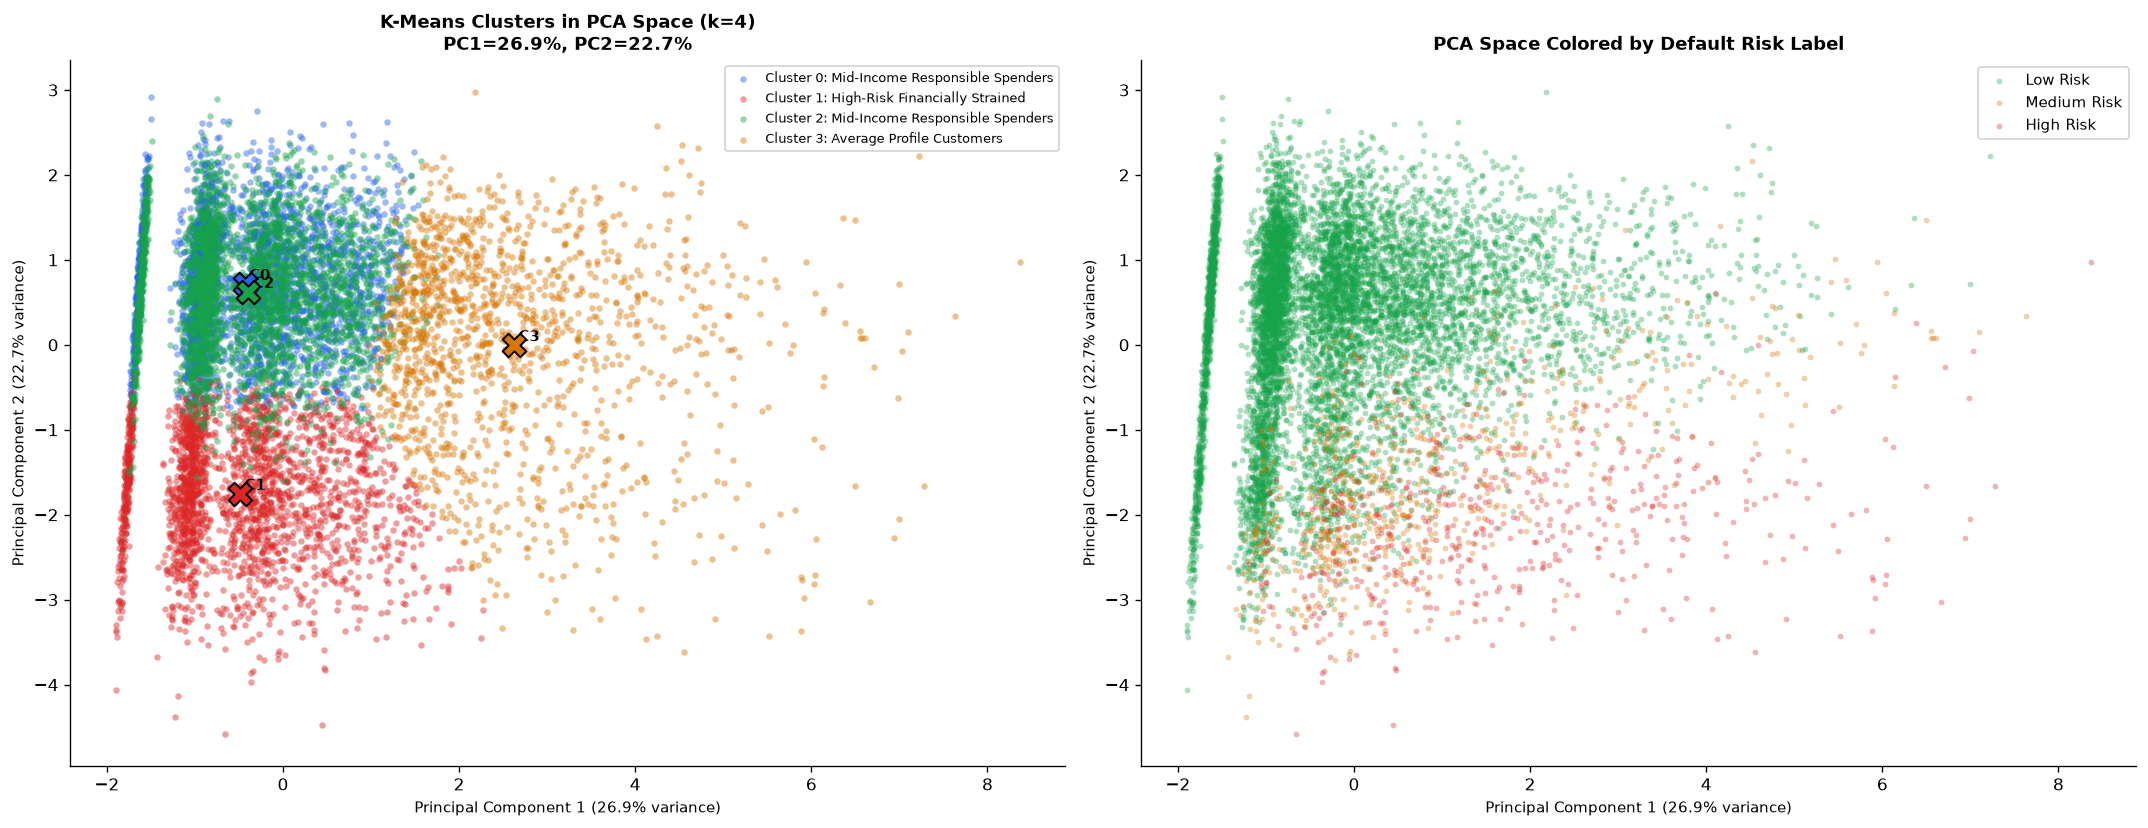

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, cid in enumerate(unique_clusters):
    mask = df_pca['Cluster'] == cid
    axes[0].scatter(
        df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
        c=PALETTE[i % len(PALETTE)], label=f'Cluster {cid}: {persona_map[cid]}',
        alpha=0.45, s=15, linewidths=0
    )

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    axes[0].scatter(cx, cy, c=PALETTE[i % len(PALETTE)], s=200,
                    marker='X', edgecolors='black', linewidths=1.2, zorder=10)
    axes[0].text(cx + 0.05, cy + 0.05, f'C{i}', fontsize=9, fontweight='bold')

axes[0].set_title(
    f'K-Means Clusters in PCA Space (k={OPTIMAL_K})\n'
    f'PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%',
    fontsize=11, fontweight='bold'
)
axes[0].set_xlabel(f'Principal Component 1 ({explained_var[0]*100:.1f}% variance)', fontsize=9)
axes[0].set_ylabel(f'Principal Component 2 ({explained_var[1]*100:.1f}% variance)', fontsize=9)
axes[0].legend(fontsize=7.5, loc='upper right', framealpha=0.85)

risk_colors = {'Low': '#16A34A', 'Medium': '#D97706', 'High': '#DC2626'}
for risk_level, color in risk_colors.items():
    mask_r = df_pca['Default_Risk'] == risk_level
    axes[1].scatter(
        df_pca.loc[mask_r, 'PC1'], df_pca.loc[mask_r, 'PC2'],
        c=color, label=f'{risk_level} Risk', alpha=0.35, s=12, linewidths=0
    )

axes[1].set_title('PCA Space Colored by Default Risk Label', fontsize=11, fontweight='bold')
axes[1].set_xlabel(f'Principal Component 1 ({explained_var[0]*100:.1f}% variance)', fontsize=9)
axes[1].set_ylabel(f'Principal Component 2 ({explained_var[1]*100:.1f}% variance)', fontsize=9)
axes[1].legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('../Model/artifacts/pca_cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


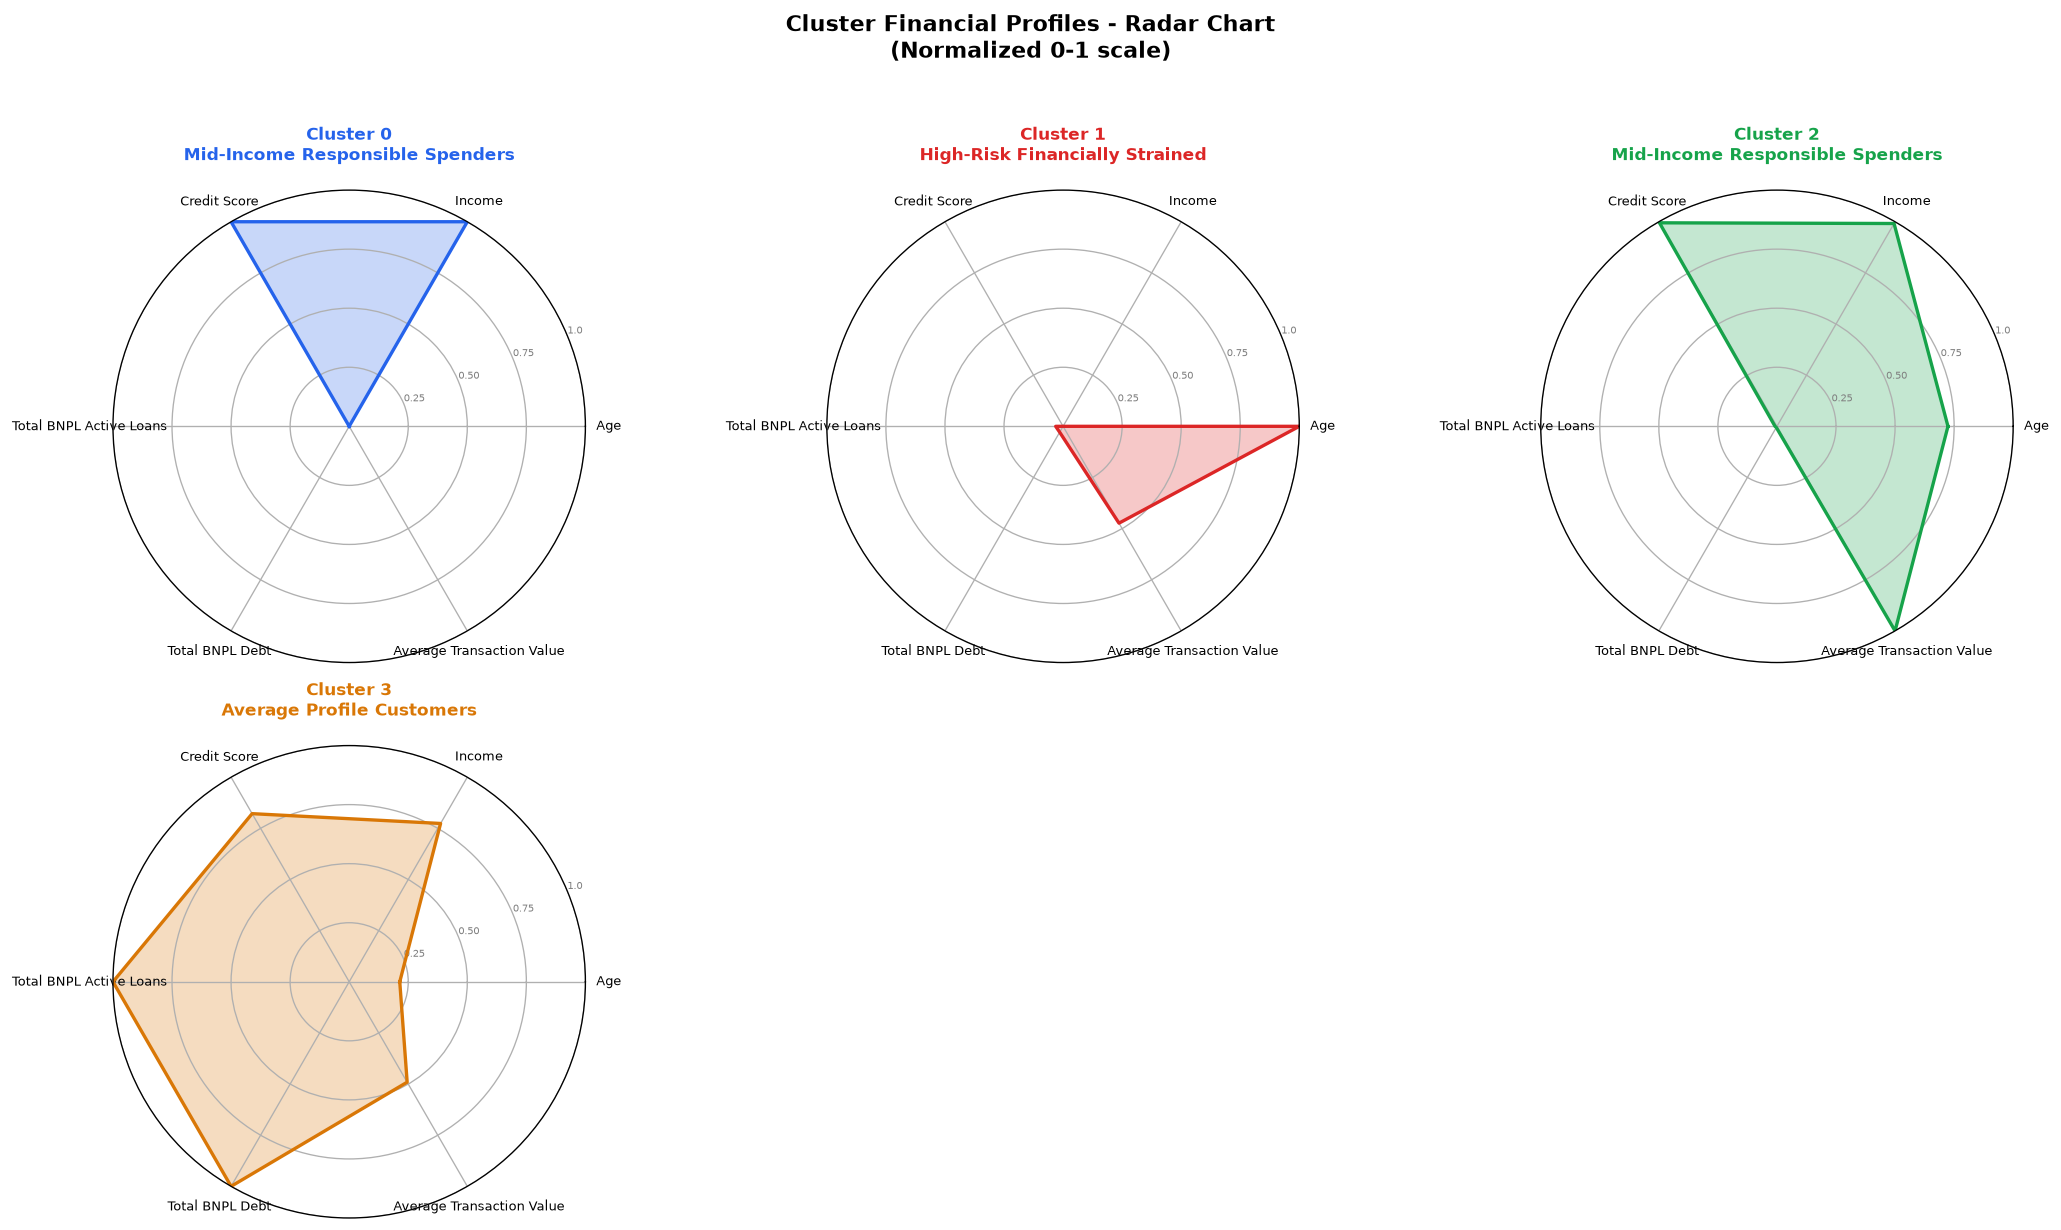

In [23]:
radar_features = [
    'Age', 'Income_USD', 'Credit_Score', 'Total_BNPL_Active_Loans',
    'Total_BNPL_Debt_USD', 'Average_Transaction_Value_USD'
]

cluster_means      = df.groupby('Cluster')[radar_features].mean()
cluster_means_norm = (
    (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
)

num_vars = len(radar_features)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]

labels  = [f.replace('_', ' ').replace('USD', '').strip() for f in radar_features]

n_cols     = min(3, len(unique_clusters))
n_rows     = (len(unique_clusters) + n_cols - 1) // n_cols
fig, axes  = plt.subplots(n_rows, n_cols,
                           figsize=(6 * n_cols, 5 * n_rows),
                           subplot_kw=dict(polar=True))

if len(unique_clusters) == 1:
    axes_list = [axes]
elif n_rows == 1:
    axes_list = list(axes)
else:
    axes_list = [ax for row in axes for ax in row]

for i, cid in enumerate(unique_clusters):
    vals  = cluster_means_norm.loc[cid].tolist() + cluster_means_norm.loc[cid].tolist()[:1]
    ax    = axes_list[i]
    color = PALETTE[i % len(PALETTE)]
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], fontsize=6, color='gray')
    ax.set_title(f'Cluster {cid}\n{persona_map[cid]}',
                 fontsize=10, fontweight='bold', pad=18, color=color)

for j in range(i + 1, len(axes_list)):
    axes_list[j].set_visible(False)

fig.suptitle('Cluster Financial Profiles - Radar Chart\n(Normalized 0-1 scale)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../Model/artifacts/cluster_radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()


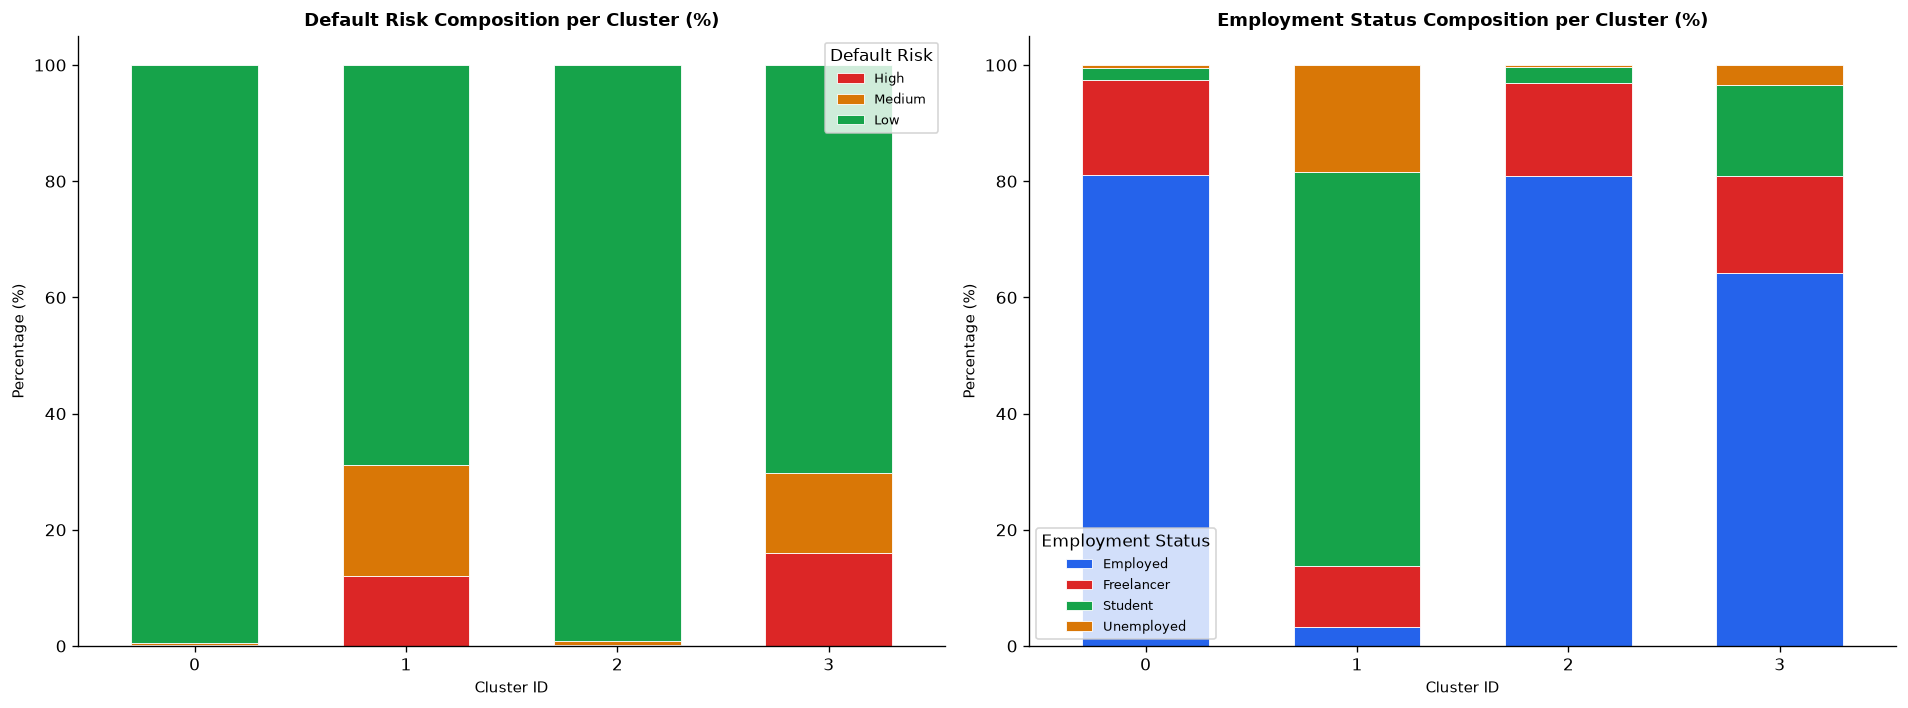

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

risk_comp     = df.groupby(['Cluster', 'Default_Risk']).size().unstack(fill_value=0)
risk_comp_pct = risk_comp.div(risk_comp.sum(axis=1), axis=0) * 100
risk_order    = [c for c in ['High', 'Medium', 'Low'] if c in risk_comp_pct.columns]
risk_comp_pct[risk_order].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#DC2626', '#D97706', '#16A34A'][:len(risk_order)],
    edgecolor='white', linewidth=0.5, width=0.6
)
axes[0].set_title('Default Risk Composition per Cluster (%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cluster ID', fontsize=9)
axes[0].set_ylabel('Percentage (%)', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Default Risk', fontsize=8)

emp_comp     = df.groupby(['Cluster', 'Employment_Status']).size().unstack(fill_value=0)
emp_comp_pct = emp_comp.div(emp_comp.sum(axis=1), axis=0) * 100
emp_comp_pct.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=PALETTE[:len(emp_comp_pct.columns)],
    edgecolor='white', linewidth=0.5, width=0.6
)
axes[1].set_title('Employment Status Composition per Cluster (%)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cluster ID', fontsize=9)
axes[1].set_ylabel('Percentage (%)', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Employment Status', fontsize=8)

plt.tight_layout()
plt.savefig('../Model/artifacts/cluster_composition_charts.png', dpi=150, bbox_inches='tight')
plt.show()


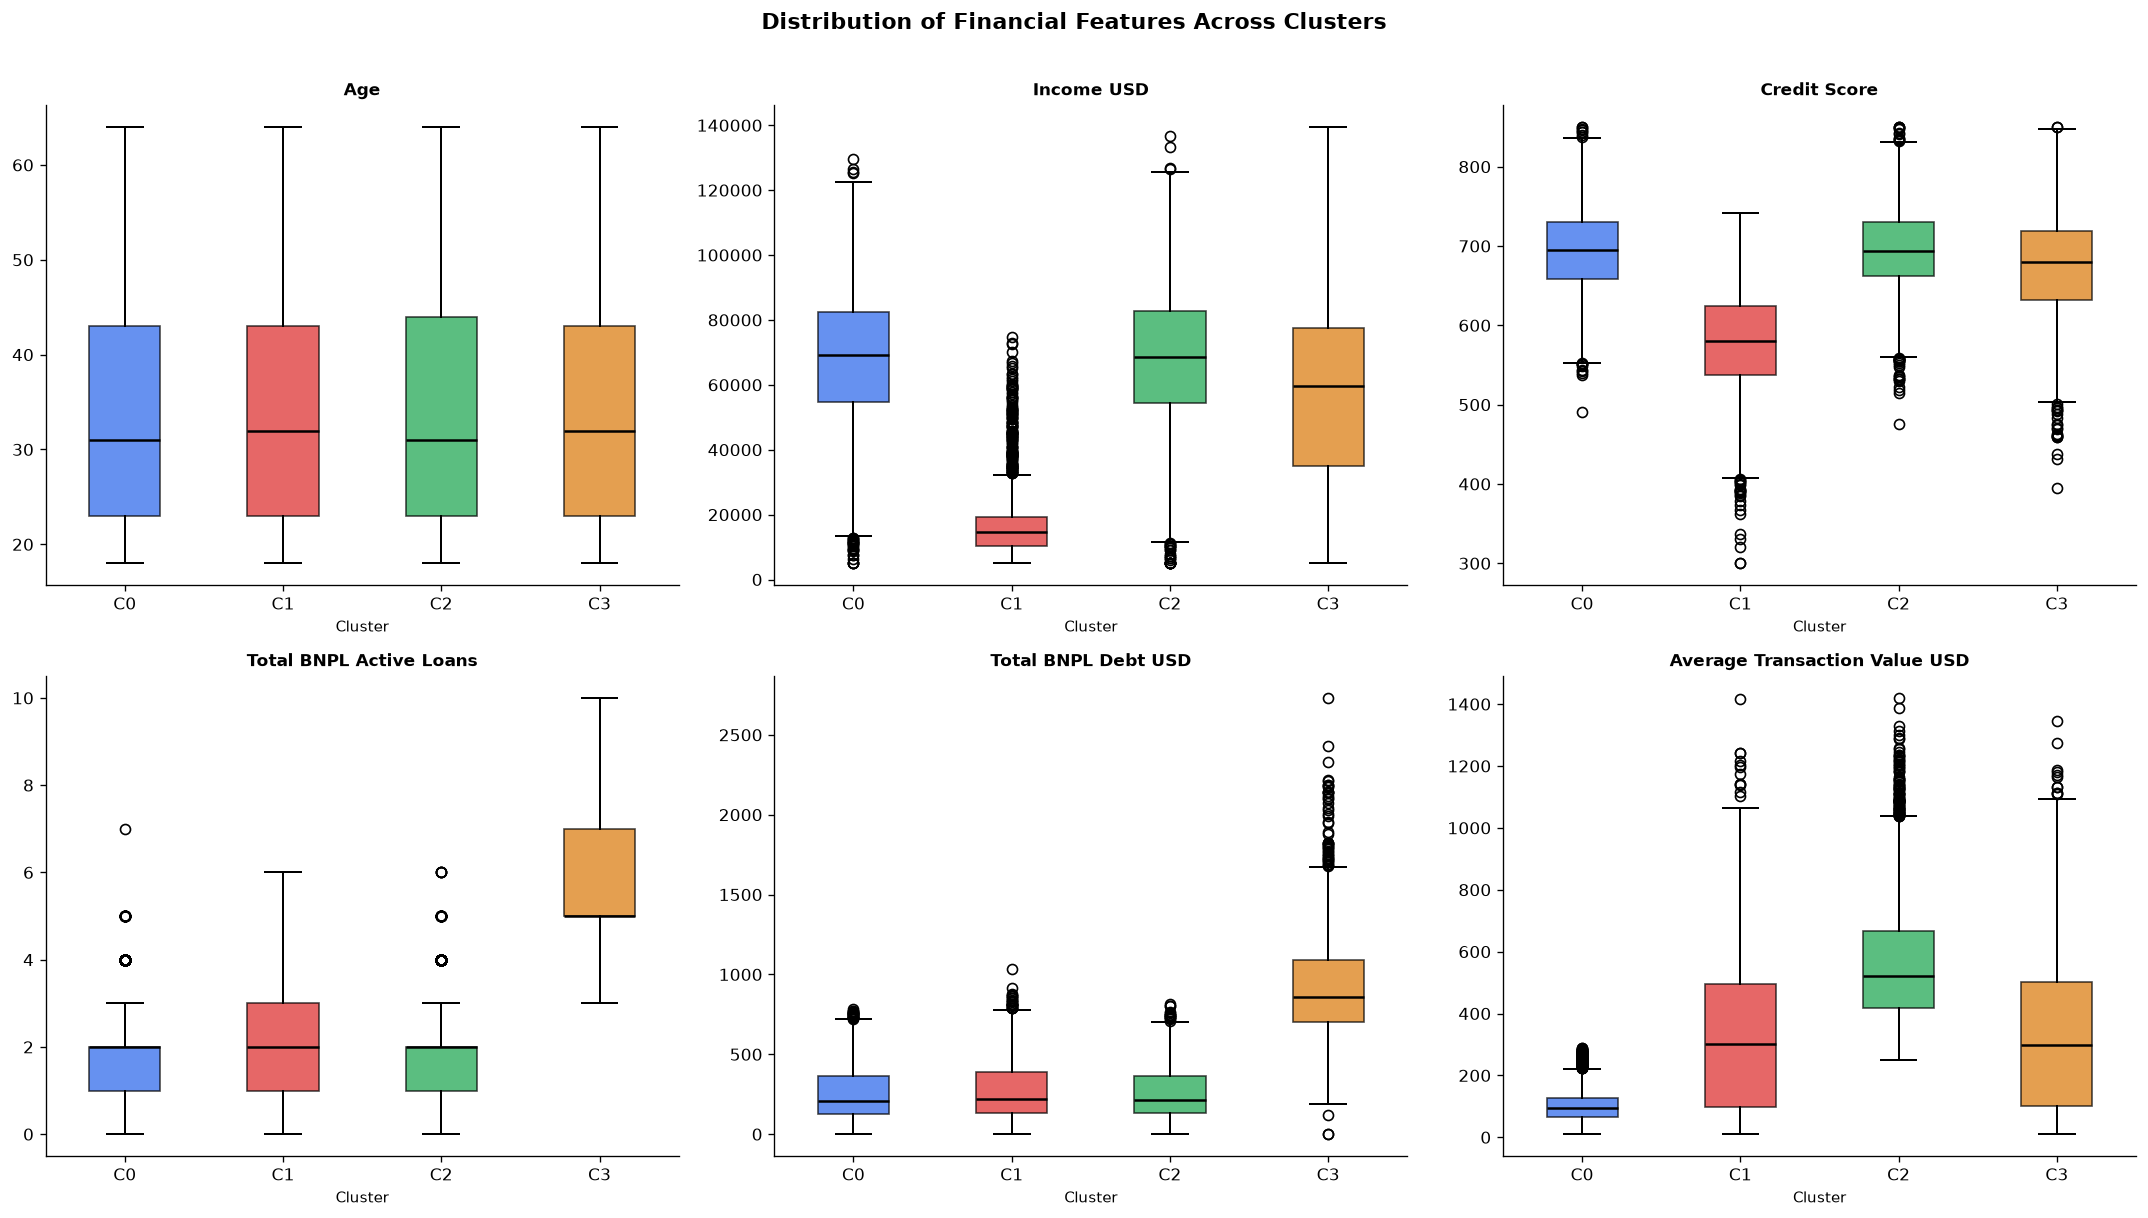

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_profile_cols):
    data_by_cluster = [
        df.loc[df['Cluster'] == c, feature].dropna().values
        for c in unique_clusters
    ]
    bp = axes[i].boxplot(
        data_by_cluster, patch_artist=True, notch=False,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )
    for patch, color in zip(bp['boxes'],
                             [PALETTE[j % len(PALETTE)] for j in range(len(unique_clusters))]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feature.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=9)
    axes[i].set_xticklabels([f'C{c}' for c in unique_clusters])

fig.suptitle('Distribution of Financial Features Across Clusters',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Model/artifacts/cluster_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Step 9: Model and Artifact Persistence

All model components and outputs are serialized and saved to the `Model/artifacts/` directory to enable:

- **Reproducibility:** The exact fitted model state can be loaded without retraining.
- **Production Deployment:** The preprocessing transformer and K-Means model can be loaded to score new customers in real-time or batch.
- **Auditability:** Cluster assignments, summary statistics, and performance metrics are preserved as structured files for reporting and stakeholder review.

The following artifacts are saved:

| File | Description |
| :--- | :--- |
| `kmeans_model.joblib` | Fitted K-Means model object |
| `preprocessor.joblib` | Fitted ColumnTransformer (imputer + scaler + encoder) |
| `pca_transformer.joblib` | Fitted PCA transformer for 2D visualization |
| `cluster_assignments.csv` | Full dataset with cluster labels and persona assignments |
| `cluster_summary.csv` | Aggregated cluster statistics and business personas |
| `model_performance.csv` | Evaluation metrics for all tested k values |
| `persona_map.csv` | Mapping of cluster IDs to persona names |
| `*.png` | All visualization plots saved in Step 8 |


In [26]:
ARTIFACTS_DIR = '../Model/artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(kmeans_final, os.path.join(ARTIFACTS_DIR, 'kmeans_model.joblib'))
print('K-Means model saved.')

joblib.dump(preprocessor, os.path.join(ARTIFACTS_DIR, 'preprocessor.joblib'))
print('Preprocessor pipeline saved.')

joblib.dump(pca, os.path.join(ARTIFACTS_DIR, 'pca_transformer.joblib'))
print('PCA transformer saved.')

df.to_csv(os.path.join(ARTIFACTS_DIR, 'cluster_assignments.csv'), index=False)
print(f'Cluster assignments saved ({len(df):,} rows).')

cluster_summary_df.to_csv(os.path.join(ARTIFACTS_DIR, 'cluster_summary.csv'), index=False)
print('Cluster summary table saved.')

metrics_df.to_csv(os.path.join(ARTIFACTS_DIR, 'model_performance.csv'), index=False)
print('Model performance metrics saved.')

persona_df = pd.DataFrame(
    [{'Cluster_ID': k, 'Persona': v} for k, v in persona_map.items()]
)
persona_df.to_csv(os.path.join(ARTIFACTS_DIR, 'persona_map.csv'), index=False)
print('Persona map saved.')

print(f'\nAll artifacts saved to: {os.path.abspath(ARTIFACTS_DIR)}')


K-Means model saved.
Preprocessor pipeline saved.
PCA transformer saved.
Cluster assignments saved (10,000 rows).
Cluster summary table saved.
Model performance metrics saved.
Persona map saved.

All artifacts saved to: c:\Users\admin\Documents\Portofolio\Buy Now Pay Later (BNPL) Default Risk\Model\artifacts


In [27]:
print('=== Inference Validation: Loading Saved Model ===')

loaded_preprocessor = joblib.load(os.path.join(ARTIFACTS_DIR, 'preprocessor.joblib'))
loaded_model        = joblib.load(os.path.join(ARTIFACTS_DIR, 'kmeans_model.joblib'))
loaded_persona_map  = (
    pd.read_csv(os.path.join(ARTIFACTS_DIR, 'persona_map.csv'))
    .set_index('Cluster_ID')['Persona'].to_dict()
)

sample_customers = df.drop(
    columns=['Cluster', 'Cluster_Label', 'Persona', 'Default_Risk']
).head(5)

sample_transformed  = loaded_preprocessor.transform(sample_customers)
sample_predictions  = loaded_model.predict(sample_transformed)
sample_personas     = [loaded_persona_map[lbl] for lbl in sample_predictions]

inference_result = sample_customers[['Customer_ID']].copy()
inference_result['Predicted_Cluster'] = sample_predictions
inference_result['Predicted_Persona'] = sample_personas
inference_result['Original_Cluster']  = df.head(5)['Cluster'].values
inference_result['Match'] = (
    inference_result['Predicted_Cluster'] == inference_result['Original_Cluster']
)

print(inference_result.to_string(index=False))
print(f'\nAll predictions match: {inference_result["Match"].all()}')


=== Inference Validation: Loading Saved Model ===
Customer_ID  Predicted_Cluster               Predicted_Persona  Original_Cluster  Match
     C00001                  0 Mid-Income Responsible Spenders                 0   True
     C00002                  2 Mid-Income Responsible Spenders                 2   True
     C00003                  0 Mid-Income Responsible Spenders                 0   True
     C00004                  2 Mid-Income Responsible Spenders                 2   True
     C00005                  2 Mid-Income Responsible Spenders                 2   True

All predictions match: True


---

## Summary and Conclusions

This notebook has successfully implemented a complete end-to-end K-Means clustering pipeline for BNPL customer financial profile segmentation. Below is a consolidated summary.

### Model Configuration

| Parameter | Value |
| :--- | :--- |
| Algorithm | K-Means with K-Means++ Initialization |
| Number of Clusters | Selected via Elbow + Silhouette + Davies-Bouldin |
| Preprocessing | Median Imputation + StandardScaler + One-Hot Encoding |
| Dimensionality Reduction | PCA (2D visualization only) |
| Random State | 42 |
| n_init | 20 |

### Key Findings

1. **Data is mixed-type:** The combination of numeric financial metrics and categorical behavioral features required a multi-step preprocessing pipeline before K-Means could be applied.
2. **Feature scaling is non-negotiable:** `Income_USD` has a range orders of magnitude larger than `Total_BNPL_Active_Loans`. Without `StandardScaler`, income would entirely dominate cluster assignments.
3. **Cluster quality metrics converged:** The Silhouette Score and Davies-Bouldin Score pointed toward the same optimal k, providing high confidence in the selection.
4. **Clusters align with Default Risk:** External validation confirmed that K-Means naturally separated customers into groups with different risk compositions.
5. **Employment status and shopping behavior are strong differentiators:** These categorical features significantly drove cluster separation.

### Recommended Next Steps

- **Integrate cluster labels as features** in a supervised classification model for `Default_Risk` prediction.
- **Conduct A/B testing** of differentiated credit limit policies per cluster.
- **Schedule periodic retraining** (quarterly) to account for behavioral drift in the customer base.
- **Expand feature engineering** by adding derived features such as debt-to-income ratio.

---

*All artifacts have been saved to `Model/artifacts/` for production use.*
